In [134]:
import pandas as pd
import numpy as np
import dask
import multiprocessing as mp
import datetime
import time
import dask.dataframe as dd
import dask.array as da
import dask.bag as bd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from dask_ml.model_selection import train_test_split
import statsmodels.api as sm

In [7]:
#Data cleaning - Trips_Full Data
#dataset2
Trips_FD = pd.read_csv ("Trips_Full Data.csv")
Trips_FD.head(7) #Displays the first 7 rows of the dataset

,Month of Date,Week of Date,Year of Date,Level,Date,Week Ending Date,Trips <1 Mile,People Not Staying at Home,Population Staying at Home,Trips,...,Trips 10-25 Miles,Trips 100-250 Miles,Trips 100+ Miles,Trips 25-100 Miles,Trips 25-50 Miles,Trips 250-500 Miles,Trips 3-5 Miles,Trips 5-10 Miles,Trips 50-100 Miles,Trips 500+ Miles
0,August,Week 32,2019,National,8/4/2019 0:00,10-Aug-19,292959749,258404133,67763287,1322685497,...,200922270,8595827,15338786,79429125,59517188,2273613,171336406,216121882,19911937,4469346
1,August,Week 32,2019,National,8/5/2019 0:00,10-Aug-19,317133861,262199758,63967662,1412564488,...,228809869,6535920,12563068,86004297,68184743,1941260,178996059,231048425,17819554,4085888
2,August,Week 32,2019,National,8/6/2019 0:00,10-Aug-19,324443205,260096133,66071287,1437762102,...,235621127,5993704,11104823,87599579,70149166,1741994,179210645,233248732,17450413,3369125
3,August,Week 32,2019,National,8/7/2019 0:00,10-Aug-19,358483024,258878802,67288618,1543710309,...,249988663,5379881,8528574,92200386,74381367,1272248,189163336,243872277,17819019,1876445
4,August,Week 32,2019,National,8/8/2019 0:00,10-Aug-19,300765870,262410045,63757375,1382044815,...,226055368,6259735,12892348,84193587,66724543,1957888,179346163,230933709,17469044,4674725
5,August,Week 32,2019,National,8/9/2019 0:00,10-Aug-19,341515854,272101417,54066003,1501571863,...,245571995,7635743,12256537,95005653,74512584,1823661,186257669,242027669,20493069,2797133
6,August,Week 32,2019,National,8/10/2019 0:00,10-Aug-19,346532975,267638064,58529356,1491503216,...,230580285,7550100,12173176,91829556,70644329,1794030,186580557,236858554,21185227,2829046


In [8]:
#Read and displays the dataset
Trips_FD.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Month of Date               7 non-null      object
 1   Week of Date                7 non-null      object
 2   Year of Date                7 non-null      int64 
 3   Level                       7 non-null      object
 4   Date                        7 non-null      object
 5   Week Ending Date            7 non-null      object
 6   Trips <1 Mile               7 non-null      int64 
 7   People Not Staying at Home  7 non-null      int64 
 8   Population Staying at Home  7 non-null      int64 
 9   Trips                       7 non-null      int64 
 10  Trips 1-25 Miles            7 non-null      int64 
 11  Trips 1-3 Miles             7 non-null      int64 
 12  Trips 10-25 Miles           7 non-null      int64 
 13  Trips 100-250 Miles         7 non-null      int64 
 14

In [9]:
#checks for missing values and if none then there is no removal 
Trips_FD.isna().sum()

Month of Date                 0
Week of Date                  0
Year of Date                  0
Level                         0
Date                          0
Week Ending Date              0
Trips <1 Mile                 0
People Not Staying at Home    0
Population Staying at Home    0
Trips                         0
Trips 1-25 Miles              0
Trips 1-3 Miles               0
Trips 10-25 Miles             0
Trips 100-250 Miles           0
Trips 100+ Miles              0
Trips 25-100 Miles            0
Trips 25-50 Miles             0
Trips 250-500 Miles           0
Trips 3-5 Miles               0
Trips 5-10 Miles              0
Trips 50-100 Miles            0
Trips 500+ Miles              0
dtype: int64

In [10]:
#check for duplicates and if none then there is no removal
Trips_FD.duplicated().sum()

0

In [12]:
Trips_FD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Month of Date               7 non-null      object
 1   Week of Date                7 non-null      object
 2   Year of Date                7 non-null      int64 
 3   Level                       7 non-null      object
 4   Date                        7 non-null      object
 5   Week Ending Date            7 non-null      object
 6   Trips <1 Mile               7 non-null      int64 
 7   People Not Staying at Home  7 non-null      int64 
 8   Population Staying at Home  7 non-null      int64 
 9   Trips                       7 non-null      int64 
 10  Trips 1-25 Miles            7 non-null      int64 
 11  Trips 1-3 Miles             7 non-null      int64 
 12  Trips 10-25 Miles           7 non-null      int64 
 13  Trips 100-250 Miles         7 non-null      int64 
 14

In [13]:
#question 1 a)
Trips_FD = dd.read_csv ("Trips_Full Data.csv")
Trips_FD['Week of Date'].nunique().compute()

1

In [139]:
trips_not_staying = Trips_FD.groupby(by='Week of Date')[['Trips <1 Mile', 'Trips 1-3 Miles', 'Trips 3-5 Miles', 'Trips 5-10 Miles', \
            'Trips 1-25 Miles', 'Trips 10-25 Miles', 'Trips 25-50 Miles', 'Trips 25-100 Miles', 'Trips 50-100 Miles', \
            'Trips 100-250 Miles', 'Trips 100+ Miles', 'Trips 250-500 Miles', 'Trips 500+ Miles']].mean().compute()

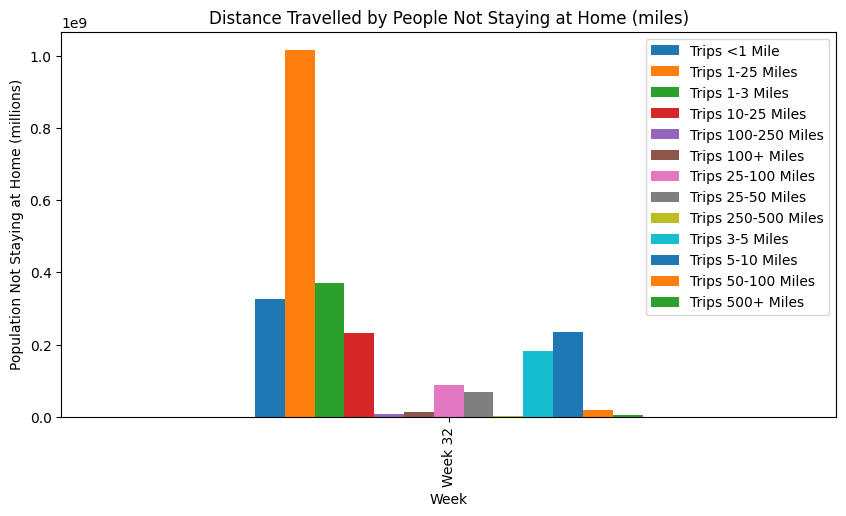

In [140]:
trips_not_staying.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Week')
plt.ylabel('Population Not Staying at Home (millions)')
plt.title('Distance Travelled by People Not Staying at Home (miles)')
plt.show()

In [40]:
trips_not_staying.describe()

,Trips <1 Mile,Trips 1-25 Miles,Trips 1-3 Miles,Trips 10-25 Miles,Trips 100-250 Miles,Trips 100+ Miles,Trips 25-100 Miles,Trips 25-50 Miles,Trips 250-500 Miles,Trips 3-5 Miles,Trips 5-10 Miles,Trips 50-100 Miles,Trips 500+ Miles
count,1.000000e+00,1.000000e+00,1.000000e+00,1.0,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.0,1.000000e+00,1.0,1.000000e+00,1.000000e+00
mean,3.259764e+08,1.015555e+09,3.694767e+08,231078511.0,6850130.0,1.212247e+07,8.803745e+07,6.915913e+07,1829242.0,1.815558e+08,233444464.0,1.887832e+07,3.443101e+06
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,3.259764e+08,1.015555e+09,3.694767e+08,231078511.0,6850130.0,1.212247e+07,8.803745e+07,6.915913e+07,1829242.0,1.815558e+08,233444464.0,1.887832e+07,3.443101e+06
25%,3.259764e+08,1.015555e+09,3.694767e+08,231078511.0,6850130.0,1.212247e+07,8.803745e+07,6.915913e+07,1829242.0,1.815558e+08,233444464.0,1.887832e+07,3.443101e+06
50%,3.259764e+08,1.015555e+09,3.694767e+08,231078511.0,6850130.0,1.212247e+07,8.803745e+07,6.915913e+07,1829242.0,1.815558e+08,233444464.0,1.887832e+07,3.443101e+06
75%,3.259764e+08,1.015555e+09,3.694767e+08,231078511.0,6850130.0,1.212247e+07,8.803745e+07,6.915913e+07,1829242.0,1.815558e+08,233444464.0,1.887832e+07,3.443101e+06
max,3.259764e+08,1.015555e+09,3.694767e+08,231078511.0,6850130.0,1.212247e+07,8.803745e+07,6.915913e+07,1829242.0,1.815558e+08,233444464.0,1.887832e+07,3.443101e+06





Time with 10 processors: 0.024453163146972656 seconds





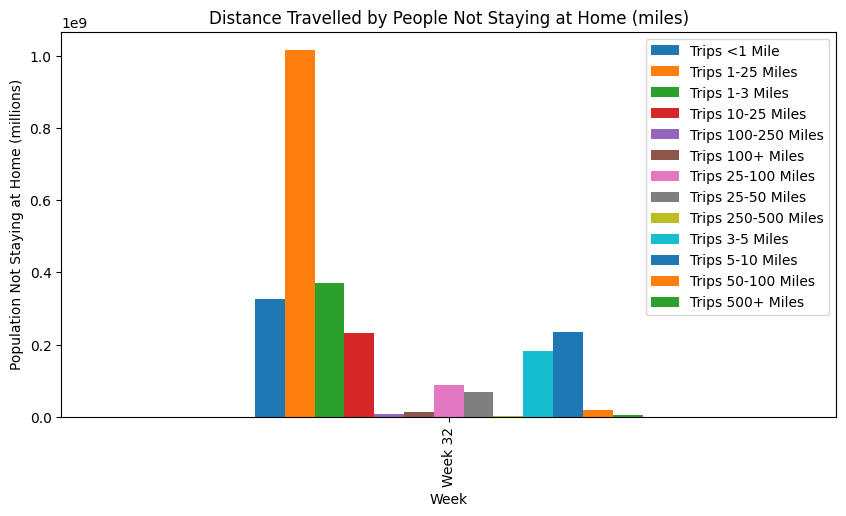




Time with 20 processors: 0.026277542114257812 seconds





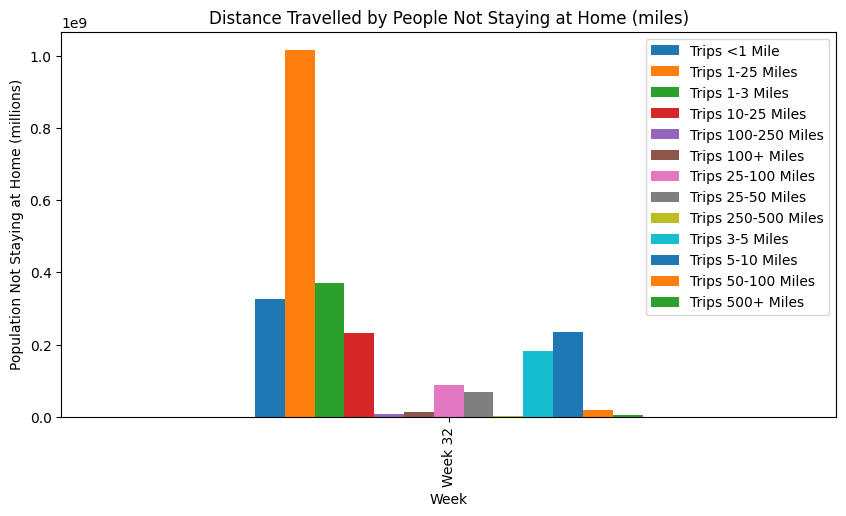

In [160]:
#question 1 c)
N_processors = [10,20]
Time_N_processors = {}
for processor in N_processors:
    start_time = time.time()
    trips_not_staying = Trips_FD.groupby(by='Week of Date')[['Trips <1 Mile', 'Trips 1-3 Miles', 'Trips 3-5 Miles', 'Trips 5-10 Miles', \
                'Trips 1-25 Miles', 'Trips 10-25 Miles', 'Trips 25-50 Miles', 'Trips 25-100 Miles', 'Trips 50-100 Miles', \
                'Trips 100-250 Miles', 'Trips 100+ Miles', 'Trips 250-500 Miles', 'Trips 500+ Miles']].mean().compute()
    dask_Time = time.time()-start_time
    Time_N_processors[processor] = dask_Time
    print(f"\n\n\nTime with {processor} processors: {dask_Time} seconds\n\n\n")
    trips_not_staying.plot (kind='bar', figsize=(10, 5))
    plt.xlabel('Week')
    plt.ylabel('Population Not Staying at Home (millions)')
    plt.title('Distance Travelled by People Not Staying at Home (miles)')
    plt.show()

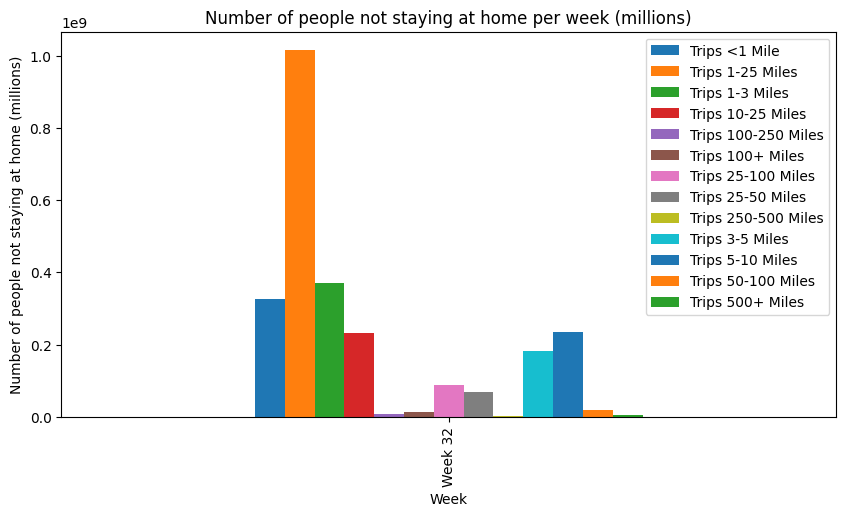

Pandas time: 0.22371983528137207seconds


In [161]:
start_time = time.time()
trips_not_staying.plot(kind='bar', figsize=(10, 5))
plt.title('Number of people not staying at home per week (millions)')
plt.xlabel('Week')
plt.ylabel('Number of people not staying at home (millions)')
plt.show()
pandas_time = time.time()-start_time
print(f"Pandas time: {pandas_time}seconds")

0.4126700288297348
coefficient of determination: 0.4126700288297348
intercept: -68484075.02367827
coefficients: [0.23235935]
predicted response:
[1.48762119e+08 1.63146423e+08 1.67271088e+08 1.83509249e+08
 1.60202371e+08 1.76142411e+08 1.73394457e+08]


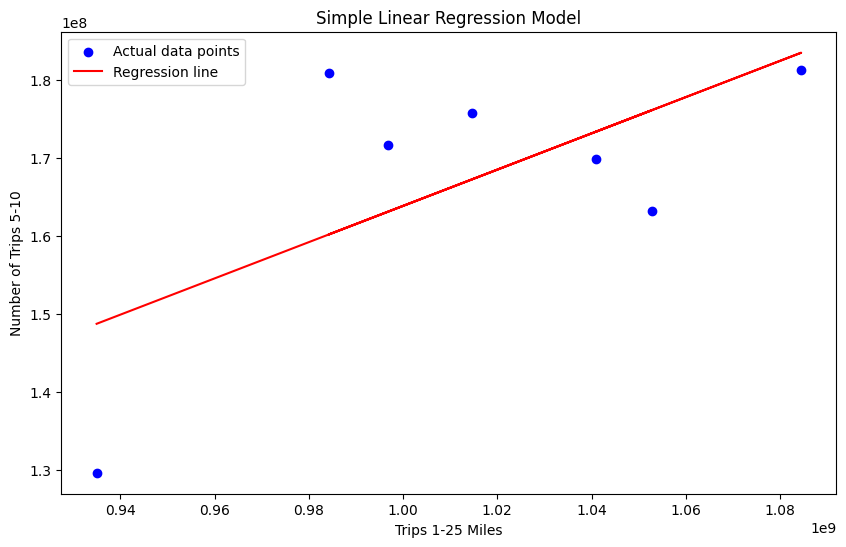

In [104]:
#question 1(d)
#simple linear regression model
Trips_FD_df = pd.read_csv("Trips_Full Data.csv")
x=Trips_FD_df.loc[:,"Trips 1-25 Miles"]  

df=pd.read_csv("Trips_By_Distance.csv")
y = df.loc[:,"Number of Trips 5-10"]

combined_df = pd.DataFrame({
    'x': x,
    'y': y
})
combined_df.dropna(inplace=True) 

x_clean = np.array(combined_df['x']).reshape((-1, 1))
y_clean = combined_df['y']

model = LinearRegression()
model.fit(x_clean, y_clean)
r_sq = model.score(x_clean, y_clean)
print(r_sq)
print(f"coefficient of determination: {r_sq}")
print(f"intercept: {model.intercept_}")
print(f"coefficients: {model.coef_}")


#Model to predict the response
y_clean_pred = model.predict(x_clean)
print(f"predicted response:\n{y_clean_pred}")

#plot
plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, color='blue', label='Actual data points')

# Plot regression line
plt.plot(x_clean, y_clean_pred, color='red', label='Regression line')

plt.xlabel('Trips 1-25 Miles')
plt.ylabel('Number of Trips 5-10')
plt.title('Simple Linear Regression Model')
plt.legend()
plt.show()


0          129670778.0
1          171637514.0
2          175775410.0
3          181324645.0
4          180941769.0
              ...     
1048570         4114.0
1048571         6450.0
1048572         6670.0
1048573        12374.0
1048574        73881.0
Name: Number of Trips 5-10, Length: 1048575, dtype: float64
0.4126700288297348
coefficient of determination: 0.4126700288297348
intercept: -68484075.02367827
coefficients: [0.23235935]
predicted response:
[1.48762119e+08 1.63146423e+08 1.67271088e+08 1.83509249e+08
 1.60202371e+08 1.76142411e+08 1.73394457e+08]


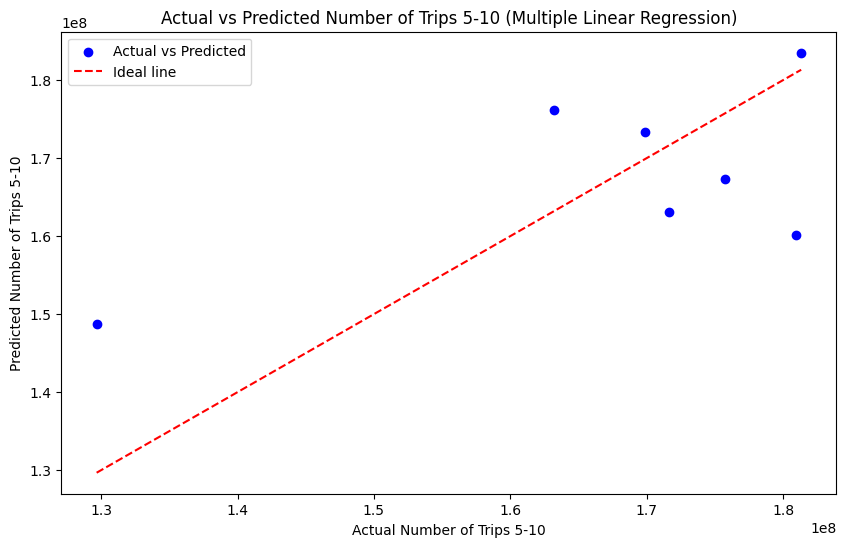

In [109]:
#Multiple linear regression for question 1(d)
x_clean, y_clean = np.array(x_clean), np.array(y_clean)
y=df.loc[:,"Number of Trips 5-10"]
print(y)

model = LinearRegression()
model.fit(x_clean, y_clean)
r_sq = model.score(x_clean, y_clean)
print(r_sq)
print(f"coefficient of determination: {r_sq}")
print(f"intercept: {model.intercept_}")
print(f"coefficients: {model.coef_}")

#Model to predict the response
y_clean_pred = model.predict(x_clean) 
print(f"predicted response:\n{y_clean_pred}")


#plot
plt.figure(figsize=(10, 6))
plt.scatter(y_clean, y_clean_pred, color='blue', label='Actual vs Predicted')
plt.plot([min(y_clean), max(y_clean)], [min(y_clean), max(y_clean)], color='red', linestyle='--', label='Ideal line')
plt.xlabel('Actual Number of Trips 5-10')
plt.ylabel('Predicted Number of Trips 5-10')
plt.title('Actual vs Predicted Number of Trips 5-10 (Multiple Linear Regression)')
plt.legend()
plt.show()

coefficient of determination: 0.6639517319983813
intercept: -3795323865.9044695
coefficients: [ 7.62831426e+00 -3.66171197e-09]
predicted response:
[1.35956885e+08 1.70286032e+08 1.74952158e+08 1.70896639e+08
 1.65544104e+08 1.77168868e+08 1.77623432e+08]


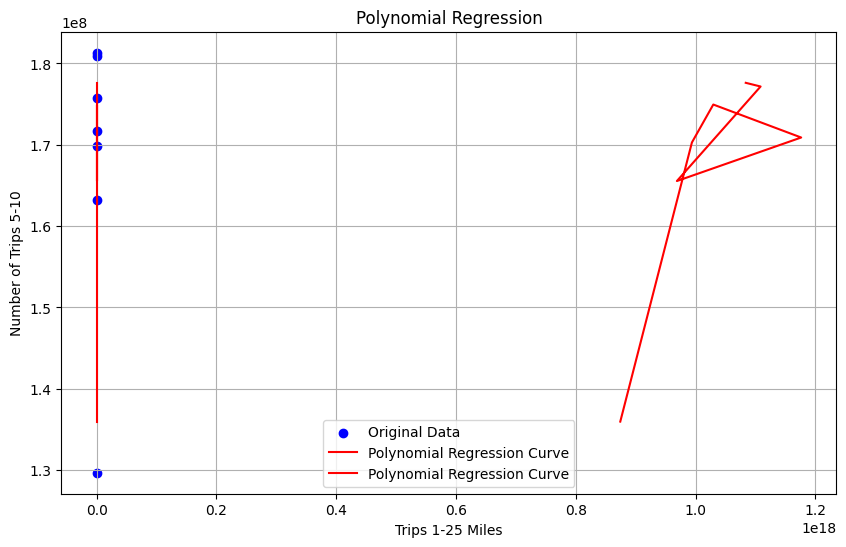

In [106]:
#polynomial regression model for question 1(d)
x=Trips_FD_df.loc[:,"Trips 1-25 Miles"]  
x_clean, y_clean = np.array(x_clean), np.array(y_clean)

x_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(x_clean) 
model=LinearRegression().fit(x_,y_clean) 
r_sq = model.score(x_, y_clean) 
intercept, coefficients = model.intercept_, model.coef_ 
y_pred = model.predict(x_)
print(f"coefficient of determination: {r_sq}")
print(f"intercept: {intercept}")
print(f"coefficients: {coefficients}")
print(f"predicted response:\n{y_pred}")


plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, color='blue', label='Original Data')
plt.plot(x_, y_pred, color='red', label='Polynomial Regression Curve')
plt.xlabel('Trips 1-25 Miles')
plt.ylabel('Number of Trips 5-10')
plt.title('Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.994
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                              994.2
Date:                Tue, 16 Apr 2024   Prob (F-statistic):                    6.76e-08
Time:                        20:49:48   Log-Likelihood:                         -124.61
No. Observations:                   7   AIC:                                      251.2
Df Residuals:                       6   BIC:                                      251.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\purvi\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


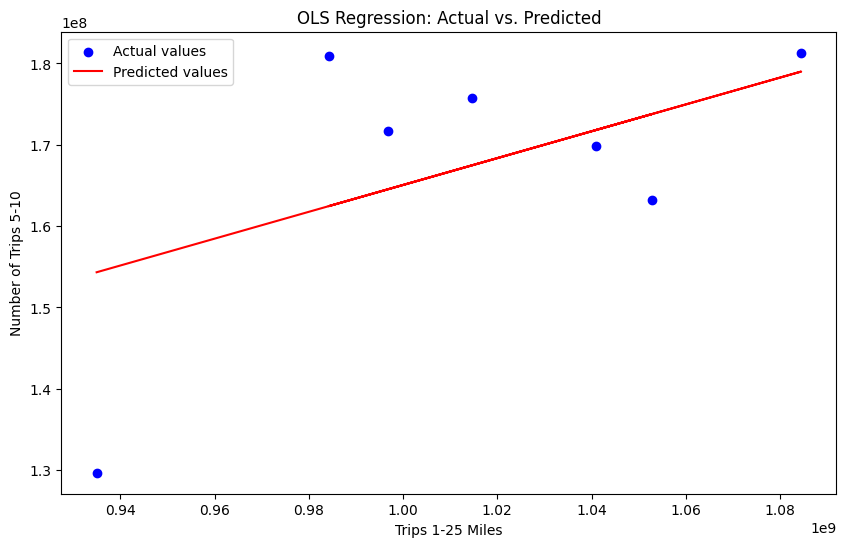

In [115]:
#Advanced Linear Regression With statsmodels for question 1(d)
model = sm.OLS(y_clean, x_clean)
results = model.fit()
print(results.summary())
print(f"coefficient of determination: {results.rsquared}")
print(f"adjusted coefficient of determination: {results.rsquared_adj}")
print(f"regression coefficients: {results.params}")
print(f"predicted response:\n{results.fittedvalues}")
print(f"predicted response:\n{results.predict(x)}")

#Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, color='blue', label='Actual values')
plt.plot(x_clean, results.predict(x_clean), color='red', label='Predicted values')

plt.xlabel('Trips 1-25 Miles')
plt.ylabel('Number of Trips 5-10')
plt.title('OLS Regression: Actual vs. Predicted')
plt.legend()
plt.show()

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.992
Method:                 Least Squares   F-statistic:                              741.3
Date:                Tue, 16 Apr 2024   Prob (F-statistic):                    1.25e-06
Time:                        21:01:50   Log-Likelihood:                         -107.12
No. Observations:                   6   AIC:                                      216.2
Df Residuals:                       5   BIC:                                      216.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\purvi\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


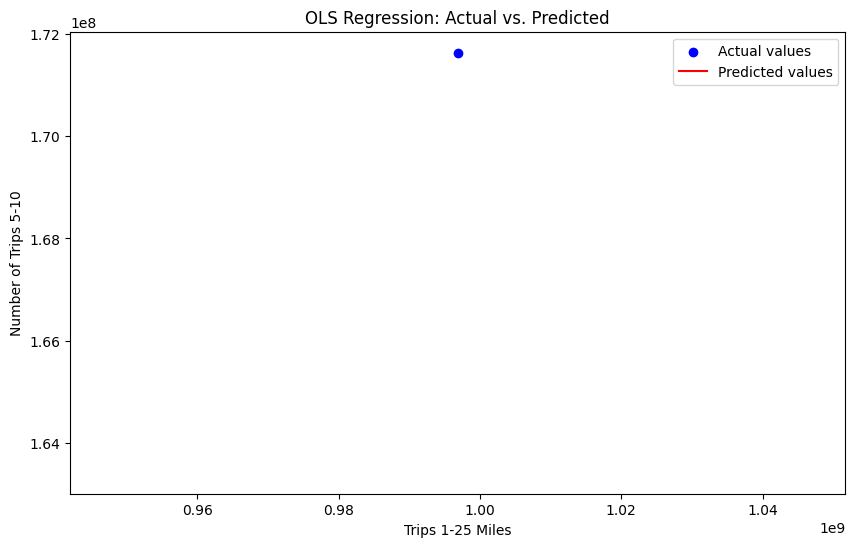

In [131]:
#Model training and testing for question 1(d)
import dask_ml.model_selection as dcv 


x_clean, y_clean = np.array(x_clean), np.array(y_clean)


X_train, X_test, y_train, y_test = dcv.train_test_split(x_clean, y_clean, shuffle=True)


model = sm.OLS(y_train, X_train)
results = model.fit()

print(results.summary())
print(f"coefficient of determination: {results.rsquared}")
print(f"adjusted coefficient of determination: {results.rsquared_adj}")
print(f"regression coefficients: {results.params}")
print(f"predicted response:\n{results.fittedvalues}")
print(f"predicted response:\n{results.predict(X_test)}")


plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual values')
plt.plot(X_test, results.predict(X_test), color='red', label='Predicted values')

plt.xlabel('Trips 1-25 Miles')
plt.ylabel('Number of Trips 5-10')
plt.title('OLS Regression: Actual vs. Predicted')
plt.legend()
plt.show()



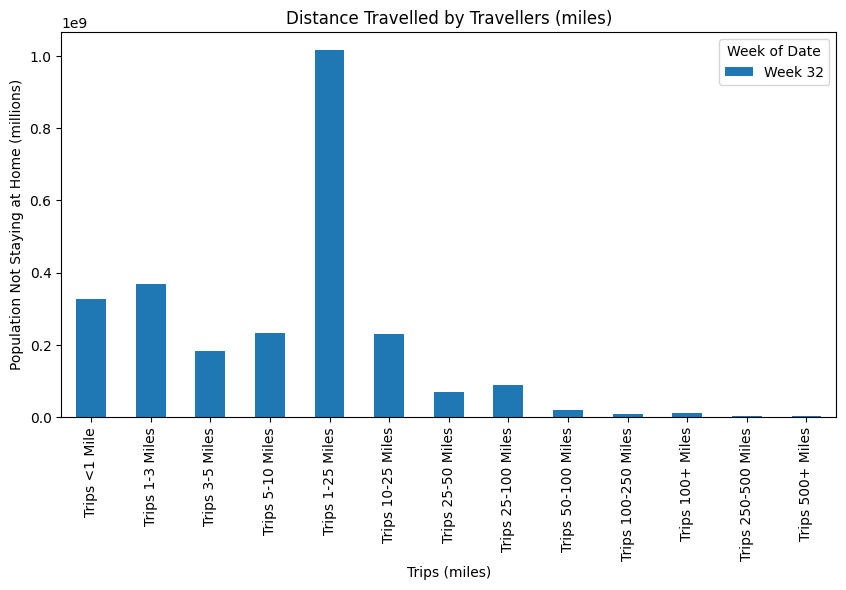

In [48]:
#question 1 e)
travellers_distance = Trips_FD.groupby(by='Week of Date')[['Trips <1 Mile', 'Trips 1-3 Miles', 'Trips 3-5 Miles', 'Trips 5-10 Miles', \
            'Trips 1-25 Miles', 'Trips 10-25 Miles', 'Trips 25-50 Miles', 'Trips 25-100 Miles', 'Trips 50-100 Miles', \
            'Trips 100-250 Miles', 'Trips 100+ Miles', 'Trips 250-500 Miles', 'Trips 500+ Miles']].mean().compute()  

Trips_order = ['Trips <1 Mile', 'Trips 1-3 Miles', 'Trips 3-5 Miles', 'Trips 5-10 Miles',
                 'Trips 1-25 Miles', 'Trips 10-25 Miles', 'Trips 25-50 Miles', 'Trips 25-100 Miles',
                 'Trips 50-100 Miles', 'Trips 100-250 Miles', 'Trips 100+ Miles',
                 'Trips 250-500 Miles', 'Trips 500+ Miles']

# Reorder the columns of the DataFrame according to the desired order
travellers_distance_ordered = travellers_distance[Trips_order]
 
travellers_distance_ordered.T.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Trips (miles)')
plt.ylabel('Population Not Staying at Home (millions)')
plt.title('Distance Travelled by Travellers (miles)')
plt.show()